<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/Homocedasticity_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

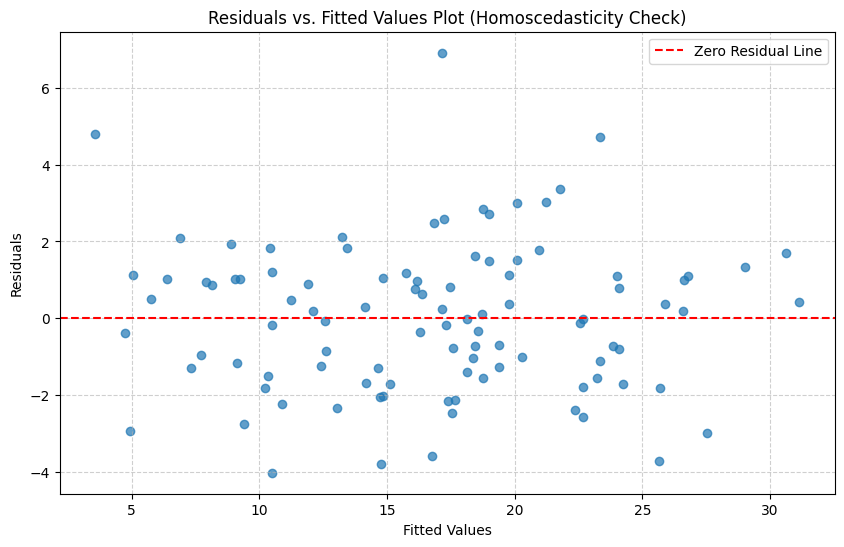

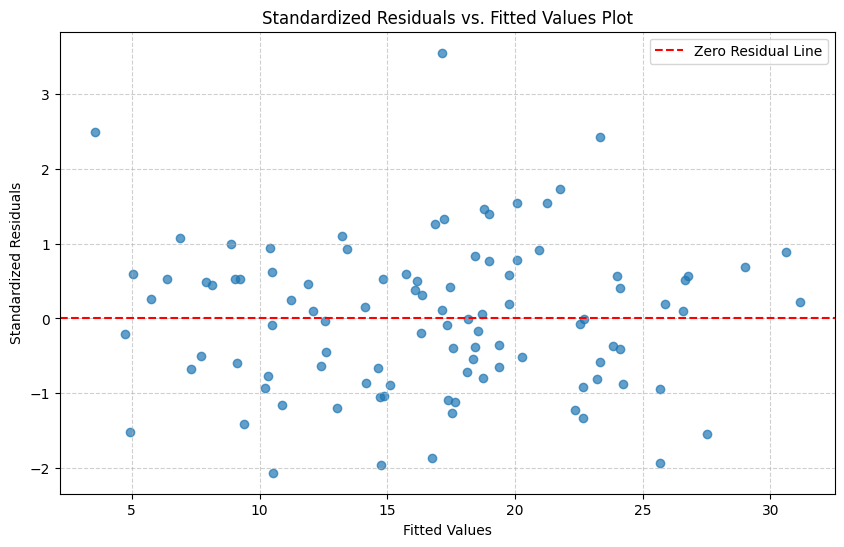

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create some sample data (replace with your actual data)
np.random.seed(42)
num_samples = 100
X = pd.DataFrame({
    'feature1': np.random.rand(num_samples) * 10,
    'feature2': np.random.rand(num_samples) * 5
})
# Add a constant for the intercept
X = sm.add_constant(X)
true_coefficients = np.array([2, 1.5, 3])
# Homoscedastic error
errors = np.random.normal(0, 2, num_samples)
y = X.dot(true_coefficients) + errors

# 2. Fit the OLS model
model = sm.OLS(y, X).fit()

# 3. Get the residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# 4. Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot (Homoscedasticity Check)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# You can also plot standardized residuals for a more robust check
standardized_residuals = model.get_influence().resid_studentized_internal

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, standardized_residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values Plot")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
    import statsmodels.api as sm
    import pandas as pd
    import numpy as np

    # Sample data
    np.random.seed(42)
    X = np.random.rand(100, 1) * 10
    y = 2 * X.squeeze() + 5 + np.random.randn(100) * 2

    # Add a constant to the independent variable for statsmodels
    X = sm.add_constant(X)

    # Fit the OLS model
    model = sm.OLS(y, X).fit()

    # Get fitted values and residuals
    fitted_values = model.fittedvalues
    residuals = model.resid

In [ ]:
    # For plotting the regression line with confidence intervals on the original data
    # (not directly for residuals vs fitted values)
    # This is an example of how to get confidence intervals for predictions
    predictions = model.get_prediction(X)
    confidence_intervals = predictions.summary_frame(alpha=0.05) # 95% CI
    ci_lower = confidence_intervals['obs_ci_lower']
    ci_upper = confidence_intervals['obs_ci_upper']

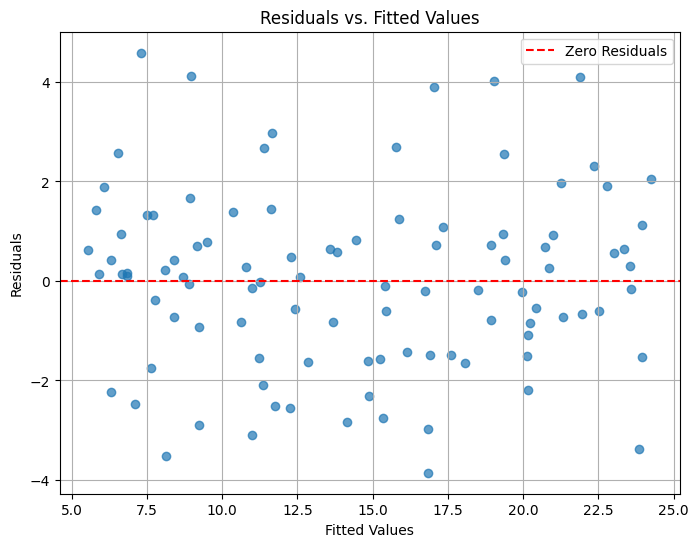

In [ ]:
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8, 6))
    plt.scatter(fitted_values, residuals, alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs. Fitted Values')
    plt.grid(True)
    plt.legend()
    plt.show()

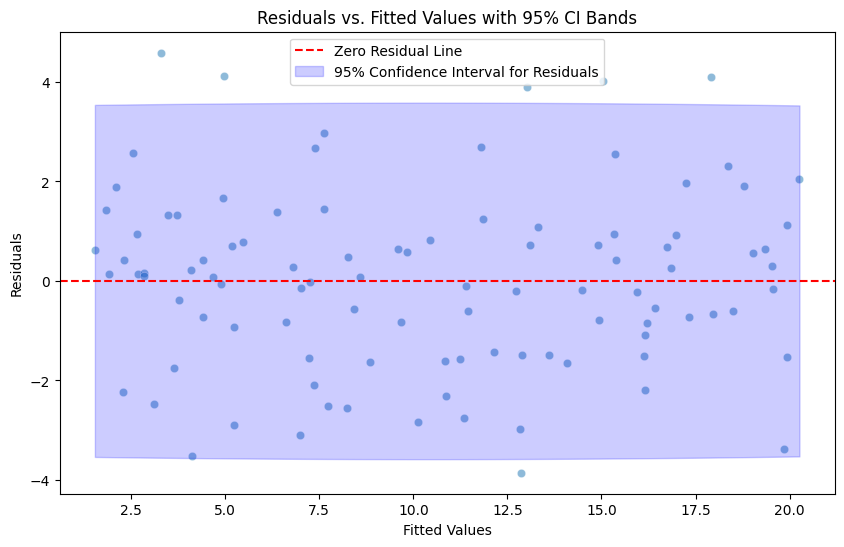

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import t

# 1. Create sample data and fit a model (using the same setup as before)
np.random.seed(42)
X_data = np.random.rand(100) * 10
y = 2 * X_data + 1 + np.random.randn(100) * 2
X = sm.add_constant(X_data) # Add a constant (intercept) to the model
model = sm.OLS(y, X).fit()

# 2. Get the fitted values and residuals
fitted_values = model.fittedvalues
residuals = model.resid

# 3. Get the standardized residuals and their confidence interval data
# The summary_frame provides 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper' etc.
# The 'mean_ci' is the confidence interval for the *mean* response (the fitted line),
# but we are plotting residuals which should ideally be within a band around 0.
# The standard error of the residuals varies across points.

# To properly plot the confidence band for residuals, we can use the standardized residuals
# and the t-distribution value, or calculate the standard error of each residual (not directly in summary_frame).

# A more direct interpretation of a "confidence interval" in this context is often
# a band around the zero line representing the expected range for residuals assuming the model is correct.

# We can use the 'stde' (standard error of the prediction) and 'mse' (mean squared error)
# to derive the confidence limits for the residuals.

# Get prediction results summary frame
prediction_summary = model.get_prediction(X).summary_frame(alpha=0.05)
# The column name for standardized residuals is 'standardized_resid'
# Let's check the actual column names in prediction_summary
# print(prediction_summary.columns)

# Based on statsmodels documentation, the standardized residuals are available directly
# from the model's influence object.
std_resid = model.get_influence().resid_studentized_internal


# The "confidence interval" for residuals can be derived from the T-statistic and stde
# A typical visual check involves plotting bounds related to the standard deviation of residuals.

# Let's use the manual calculation with correct stdev of residuals (sigma) and leverage (hat_diag)
# to get the exact standard error for each residual.

mse = model.mse_resid # Mean squared error of residuals (estimate of variance sigma^2)
hat_diag = model.get_influence().hat_matrix_diag # Leverage values
sigma = np.sqrt(mse)
# Standard error of the residual for each point: se_resid_i = sigma * sqrt(1 - h_i)
se_resid = sigma * np.sqrt(1 - hat_diag)

# For a 95% CI, we use a t-value (for large samples ~1.96)
# You can calculate the exact t-value:
t_val = t.ppf(0.975, df=model.df_resid)

# Lower and Upper bounds for the residual CI: resid_i +/- t_val * se_resid_i
ci_lower = -t_val * se_resid
ci_upper = t_val * se_resid

# 4. Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual Line')

# Sort fitted values for correct plotting of fill_between bands
sort_idx = np.argsort(fitted_values)
plt.fill_between(
    fitted_values[sort_idx],
    ci_lower[sort_idx],
    ci_upper[sort_idx],
    color='blue',
    alpha=0.2,
    label='95% Confidence Interval for Residuals'
)

plt.title('Residuals vs. Fitted Values with 95% CI Bands')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()

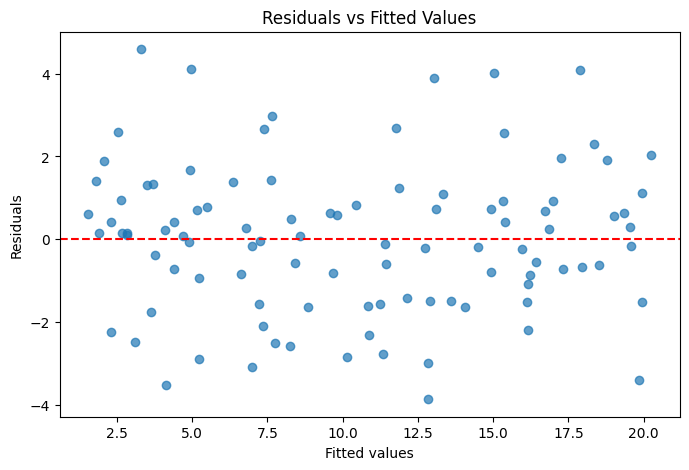

In [ ]:
# 2. Get the fitted values and residuals
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8,5))
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

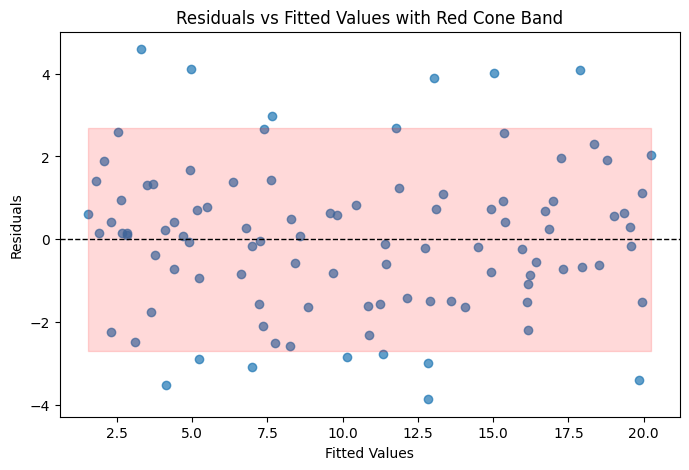

In [ ]:
# Sort by fitted values (for smooth shading)
order = np.argsort(fitted_vals)
fitted_sorted = fitted_vals[order]
resid_sorted = residuals[order]

# Define the “cone” band shape (e.g., proportional to fitted value spread)
#band_width = 1.5 * np.std(residuals) * (1 + 0.5 * np.abs(fitted_sorted - np.mean(fitted_sorted)) / np.std(fitted_sorted))
band_width = 1.5 * np.std(residuals)#* (1 + 0.5 * np.abs(fitted_sorted - np.mean(fitted_sorted)) / np.std(fitted_sorted))
upper_band = band_width
lower_band = -band_width

# Plot
plt.figure(figsize=(8,5))
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Red shaded cone
plt.fill_between(fitted_sorted, lower_band, upper_band, color='red', alpha=0.15)

plt.title('Residuals vs Fitted Values with Red Cone Band')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

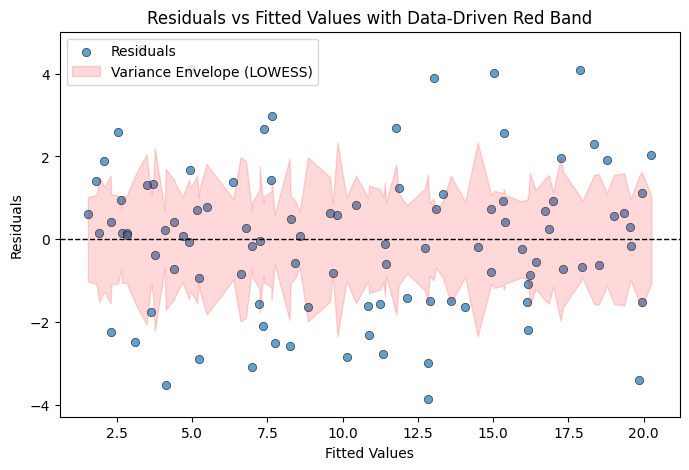

In [ ]:

# Compute LOWESS (locally weighted scatterplot smoothing)
lowess = sm.nonparametric.lowess
smooth_abs_resid = lowess(np.abs(residuals), fitted_vals, frac=0.8)  # frac controls smoothness

# Sort fitted values and smoothed residuals
sorted_fitted = np.sort(fitted_vals)
sorted_smooth = np.array([v for _, v in sorted(zip(fitted_vals, smooth_abs_resid[:,1]))])

# Plot residuals
plt.figure(figsize=(8,5))
plt.scatter(fitted_vals, residuals, alpha=0.7, label="Residuals", edgecolor='k', linewidth=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Red shaded data-driven band
plt.fill_between(sorted_fitted,
                 -sorted_smooth,
                 sorted_smooth,
                 color='red',
                 alpha=0.15,
                 label='Variance Envelope (LOWESS)')

plt.title('Residuals vs Fitted Values with Data-Driven Red Band')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()


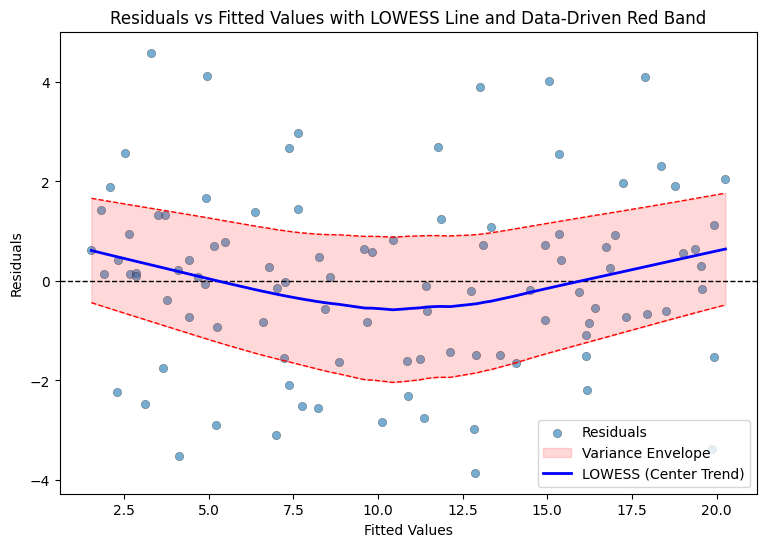

In [ ]:

# Compute LOWESS for the residual trend (center line)
lowess = sm.nonparametric.lowess
smooth_resid = lowess(residuals, fitted_vals, frac=0.6)

# Compute LOWESS for absolute residuals (variance envelope)
smooth_abs_resid = lowess(np.abs(residuals), fitted_vals, frac=0.6)

# Sort by fitted values for consistent plotting
sorted_idx = np.argsort(fitted_vals)
sorted_fitted = fitted_vals[sorted_idx]
smooth_center = np.interp(sorted_fitted, smooth_resid[:,0], smooth_resid[:,1])
smooth_spread = np.interp(sorted_fitted, smooth_abs_resid[:,0], smooth_abs_resid[:,1])

# Create upper and lower envelope lines
upper = smooth_center + smooth_spread
lower = smooth_center - smooth_spread

# Plot
plt.figure(figsize=(9,6))
plt.scatter(fitted_vals, residuals, alpha=0.6, label="Residuals", edgecolor='k', linewidth=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Shaded band
plt.fill_between(sorted_fitted, lower, upper, color='red', alpha=0.15, label='Variance Envelope')

# Edge lines
plt.plot(sorted_fitted, upper, color='red', linestyle='--', linewidth=1)
plt.plot(sorted_fitted, lower, color='red', linestyle='--', linewidth=1)

# LOWESS central trend line
plt.plot(sorted_fitted, smooth_center, color='blue', linewidth=2, label='LOWESS (Center Trend)')

plt.title('Residuals vs Fitted Values with LOWESS Line and Data-Driven Red Band')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()

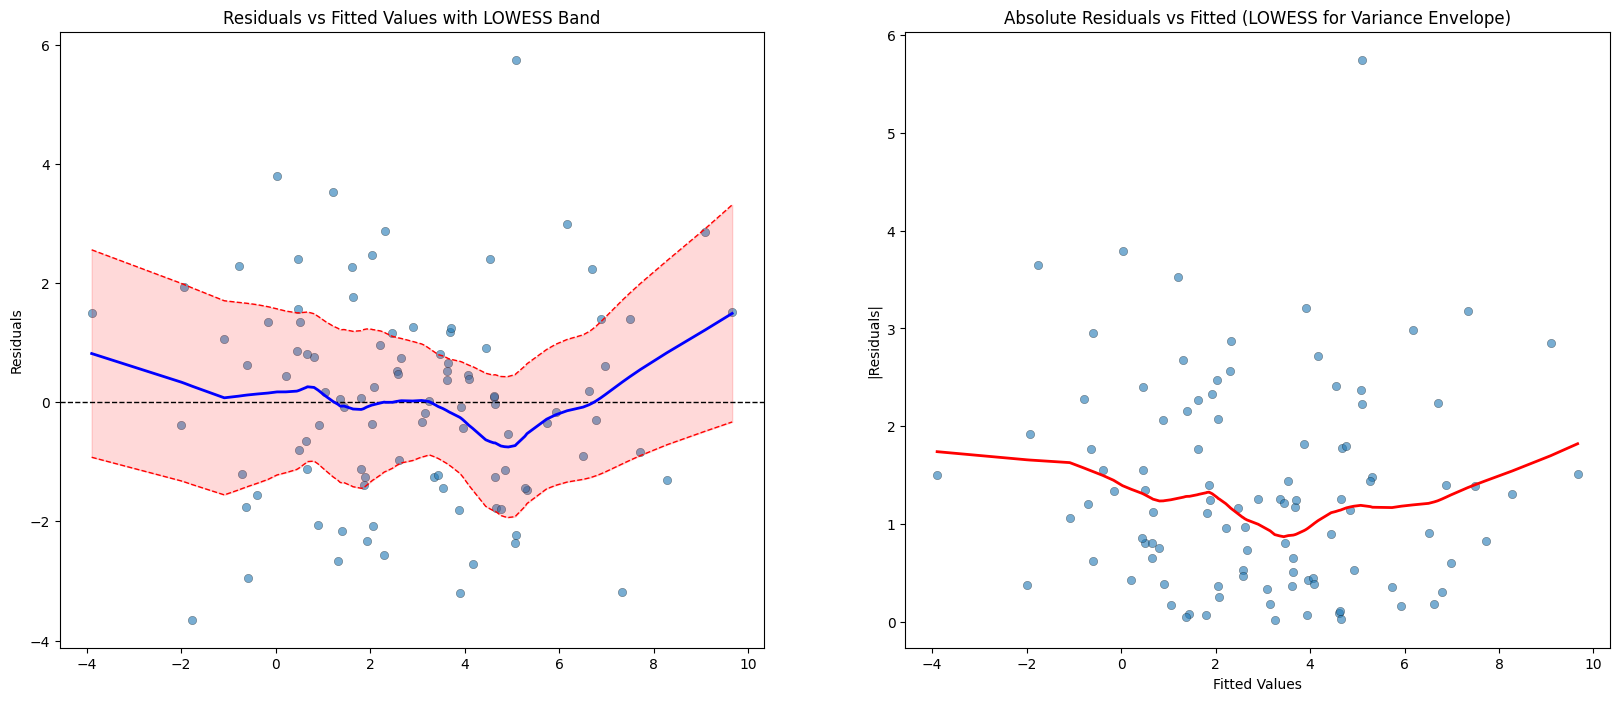

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Simulate heteroscedastic data
np.random.seed(123)
n = 100
X1 = np.random.randn(n)
X2 = np.random.randn(n)
y = 3 + 2*X1 - 1.5*X2 + np.random.randn(n) * (1 + 0.8*np.abs(X1))

# Fit model
df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})
X = sm.add_constant(df[['X1', 'X2']])
model = sm.OLS(df['y'], X).fit()

# Residuals and fitted values
fitted_vals = model.fittedvalues
residuals = model.resid

# Compute LOWESS (center and absolute residuals)
lowess = sm.nonparametric.lowess
smooth_resid = lowess(residuals, fitted_vals, frac=0.4)
smooth_abs_resid = lowess(np.abs(residuals), fitted_vals, frac=0.4)

# Sort by fitted values for consistent plotting
sorted_idx = np.argsort(fitted_vals)
sorted_fitted = fitted_vals[sorted_idx]
smooth_center = np.interp(sorted_fitted, smooth_resid[:,0], smooth_resid[:,1])
smooth_spread = np.interp(sorted_fitted, smooth_abs_resid[:,0], smooth_abs_resid[:,1])
upper = smooth_center + smooth_spread
lower = smooth_center - smooth_spread

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, gridspec_kw={'hspace': 0.3})

# --- (1) Residuals vs Fitted ---
ax = axes[0]
ax.scatter(fitted_vals, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.fill_between(sorted_fitted, lower, upper, color='red', alpha=0.15)
ax.plot(sorted_fitted, upper, color='red', linestyle='--', linewidth=1)
ax.plot(sorted_fitted, lower, color='red', linestyle='--', linewidth=1)
ax.plot(sorted_fitted, smooth_center, color='blue', linewidth=2)
ax.set_title('Residuals vs Fitted Values with LOWESS Band')
ax.set_ylabel('Residuals')

# --- (2) |Residuals| vs Fitted ---
ax2 = axes[1]
ax2.scatter(fitted_vals, np.abs(residuals), alpha=0.6, edgecolor='k', linewidth=0.3)
ax2.plot(smooth_abs_resid[:,0], smooth_abs_resid[:,1], color='red', linewidth=2)
ax2.set_title('Absolute Residuals vs Fitted (LOWESS for Variance Envelope)')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('|Residuals|')

plt.show()


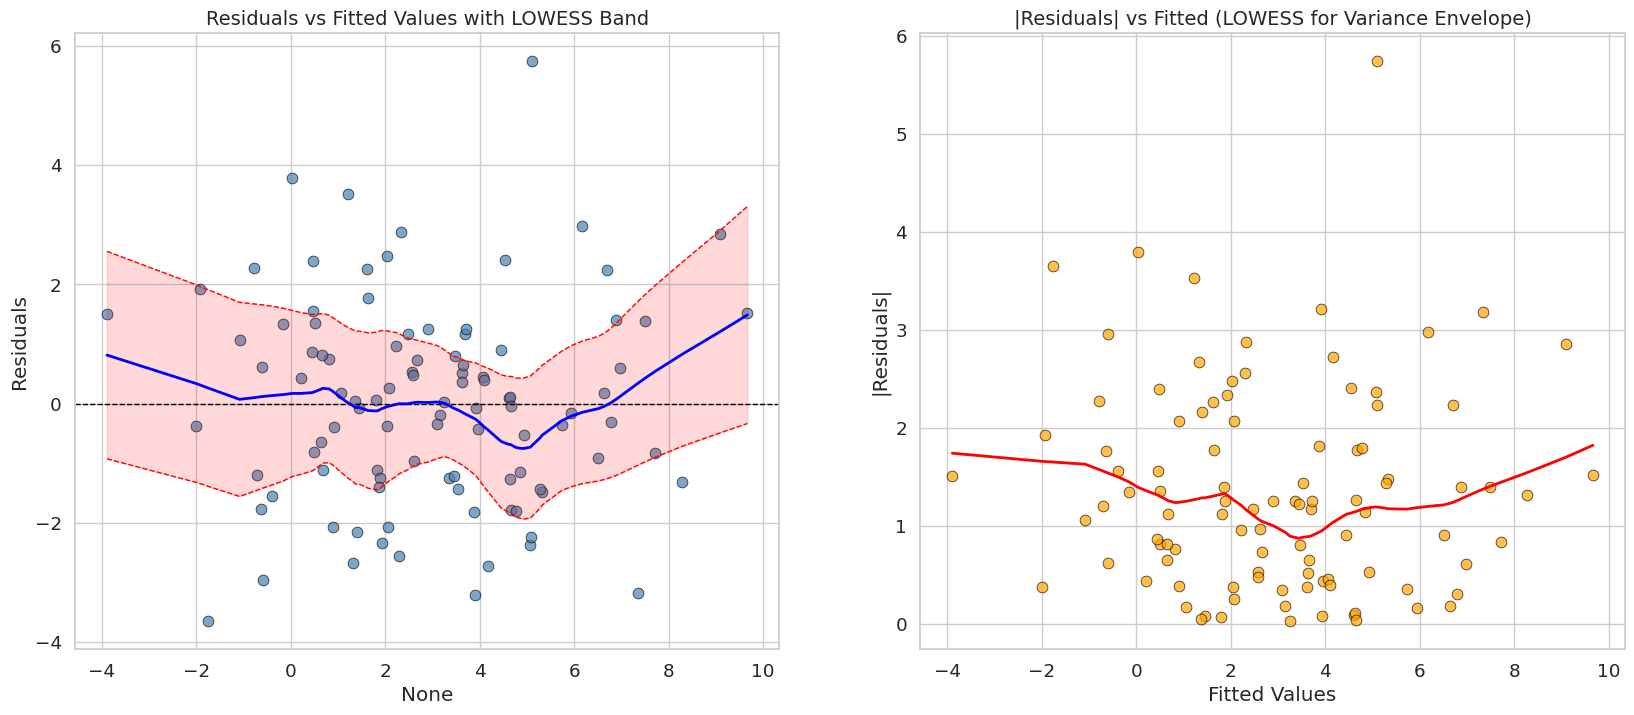

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Simulate heteroscedastic data ---
np.random.seed(123)
n = 100
X1 = np.random.randn(n)
X2 = np.random.randn(n)
y = 3 + 2*X1 - 1.5*X2 + np.random.randn(n) * (1 + 0.8*np.abs(X1))

# --- Fit OLS model ---
df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})
X = sm.add_constant(df[['X1', 'X2']])
model = sm.OLS(df['y'], X).fit()

# --- Residuals and fitted values ---
fitted_vals = model.fittedvalues
residuals = model.resid

# --- Compute LOWESS smooths ---
lowess = sm.nonparametric.lowess
smooth_resid = lowess(residuals, fitted_vals, frac=0.4)
smooth_abs_resid = lowess(np.abs(residuals), fitted_vals, frac=0.4)

# --- Sort for smooth plotting ---
sorted_idx = np.argsort(fitted_vals)
sorted_fitted = fitted_vals[sorted_idx]
smooth_center = np.interp(sorted_fitted, smooth_resid[:,0], smooth_resid[:,1])
smooth_spread = np.interp(sorted_fitted, smooth_abs_resid[:,0], smooth_abs_resid[:,1])
upper = smooth_center + smooth_spread
lower = smooth_center - smooth_spread

# --- Set Seaborn style ---
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- Create figure ---
fig, axes = plt.subplots(1,2, figsize=(20, 8), sharex=True, gridspec_kw={'hspace': 0.3})

# === (1) Residuals vs Fitted Values ===
ax = axes[0]
sns.scatterplot(x=fitted_vals, y=residuals, ax=ax, s=60, color='steelblue', edgecolor='black', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.fill_between(sorted_fitted, lower, upper, color='red', alpha=0.15)
ax.plot(sorted_fitted, upper, color='red', linestyle='--', linewidth=1)
ax.plot(sorted_fitted, lower, color='red', linestyle='--', linewidth=1)
ax.plot(sorted_fitted, smooth_center, color='blue', linewidth=2)
ax.set_title("Residuals vs Fitted Values with LOWESS Band", fontsize=14)
ax.set_ylabel("Residuals")

# === (2) |Residuals| vs Fitted ===
ax2 = axes[1]
sns.scatterplot(x=fitted_vals, y=np.abs(residuals), ax=ax2, s=60, color='orange', edgecolor='black', alpha=0.7)
sns.lineplot(x=smooth_abs_resid[:,0], y=smooth_abs_resid[:,1], ax=ax2, color='red', linewidth=2)
ax2.set_title("|Residuals| vs Fitted (LOWESS for Variance Envelope)", fontsize=14)
ax2.set_xlabel("Fitted Values")
ax2.set_ylabel("|Residuals|")

plt.show()
